# SVM - Classification

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# library for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# library for ML - SVM
#SVM Classification
from sklearn.svm import SVC
#SVM Regression
from sklearn.svm import SVR, LinearSVR

# library for preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

#filter warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from pathlib import Path
from IPython.display import Image, display

image_name = "Simple_Explanation.png"
image_path = Path(image_name)

display(Image(filename=str(image_path)))

## 1. Data Loading / Ingestion

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


In [ ]:
# convert to a dataframe

df = X.join(y)
df.head()

In [ ]:
df.info()

## Step 2 : Data Cleaning

In [ ]:
# null data
df.isnull().sum()

In [ ]:
# duplicates
df.duplicated().sum()

In [ ]:
# look at first 10 duplicates
df[df.duplicated()].head(20)

In [ ]:
# look at first row and where it is duplicated

# fixed_acidity	volatile_acidity	citric_acid	residual_sugar	chlorides	free_sulfur_dioxide	total_sulfur_dioxide	density	pH	sulphates	alcohol	quality
# 7.4	0.700	0.00	1.90	0.076	11.0	34.0	0.9978	3.51	0.56	9.4	5

df[df[df.duplicated()].head(1) == True]

In [ ]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)

In [ ]:
# remove duplicates
df = df.drop_duplicates()
df.shape

## Step 3 : EDA

In [ ]:
# check for target variable
df.quality.value_counts()

In [ ]:
# countplot
sns.countplot(x=df.quality)
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Wine Quality Distribution')
plt.show()

In [ ]:
# Two class classification with Good(for quality 7 and above) and Not Good(for less than 7)

y_class = (df.quality>=7).astype(int)
y_class.value_counts()

In [ ]:
# plot these

sns.countplot(x=y_class)
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Wine Quality Distribution')
plt.show()

## 4. Feature Engineering

In [ ]:
# Feature to training
X = df.drop('quality', axis=1)
y = y_class

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_train[:10]

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y_class)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
y_train.value_counts()

In [ ]:
y_test.value_counts()

In [ ]:
X_test.describe()

## 5. Machine Learning

In [ ]:
# pipeline
from sklearn.pipeline import Pipeline


linear_svm = Pipeline([('scaler', StandardScaler()),
                      ('linear_svc', SVC(kernel='linear'))])



In [ ]:
# fit the model with data
linear_svm.fit(X_train, y_train)

In [ ]:
# prediction
y_pred_linear = linear_svm.predict(X_test)

accuracy_linear = linear_svm.score(X_test, y_test)
print("Accuracy:", accuracy_linear)

# classification report
print(classification_report(y_test, y_pred_linear))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# coefficients of the model
linear_svm.get_params()

In [ ]:
# secondly we start with a polynomial kernel

poly_svm = Pipeline([('scaler', StandardScaler()),
                      ('poly_svc', SVC(kernel='poly', degree=3))])

poly_svm.fit(X_train, y_train)

In [ ]:
# predict
y_pred_poly = poly_svm.predict(X_test)

accuracy_poly = poly_svm.score(X_test, y_test)
print("Accuracy:", accuracy_poly)

# classification report
print(classification_report(y_test, y_pred_poly))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_poly)
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()


In [ ]:
# 3. RBF - Gaussian
rbf_svm = Pipeline([('scaler', StandardScaler()),
                      ('rbf_svc', SVC(kernel='rbf'))])

rbf_svm.fit(X_train, y_train)

In [ ]:
# prediction
y_pred_rbf = rbf_svm.predict(X_test)

accuracy_rbf = rbf_svm.score(X_test, y_test)
print("Accuracy:", accuracy_rbf)

# classification report
print(classification_report(y_test, y_pred_rbf))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


models = ['Linear', 'Polynomial', 'RBF']
accuracies = [accuracy_linear, accuracy_poly, accuracy_rbf]
f1_scores = [f1_score(y_test, y_pred_linear), f1_score(y_test, y_pred_poly), f1_score(y_test, y_pred_rbf)]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'F1 Score': f1_scores
})

# Melt the DataFrame to long format for seaborn barplot
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df_melted)
plt.title('Model Comparison: Accuracy vs F1 Score')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.show()

In [ ]:
# Experiment with C_values
C_values = [0.001, 0.01, 0.1, 1, 10]
f1_scores = []

for c in C_values:
    model = Pipeline([('scaler', StandardScaler()),
                      ('svc', SVC(kernel='linear', C=c))])
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    f1_scores.append(f1_score(y_test, pred))
    print(f"C = {c}")
    print(classification_report(y_test, pred))
    print()

In [ ]:
# plot for linear SVC at different C_levels
plt.figure(figsize=(10, 6))
plt.plot(C_values, f1_scores, marker='o')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Accuracy')
plt.title('Linear SVC Accuracy vs C')
plt.grid(True)
plt.show()

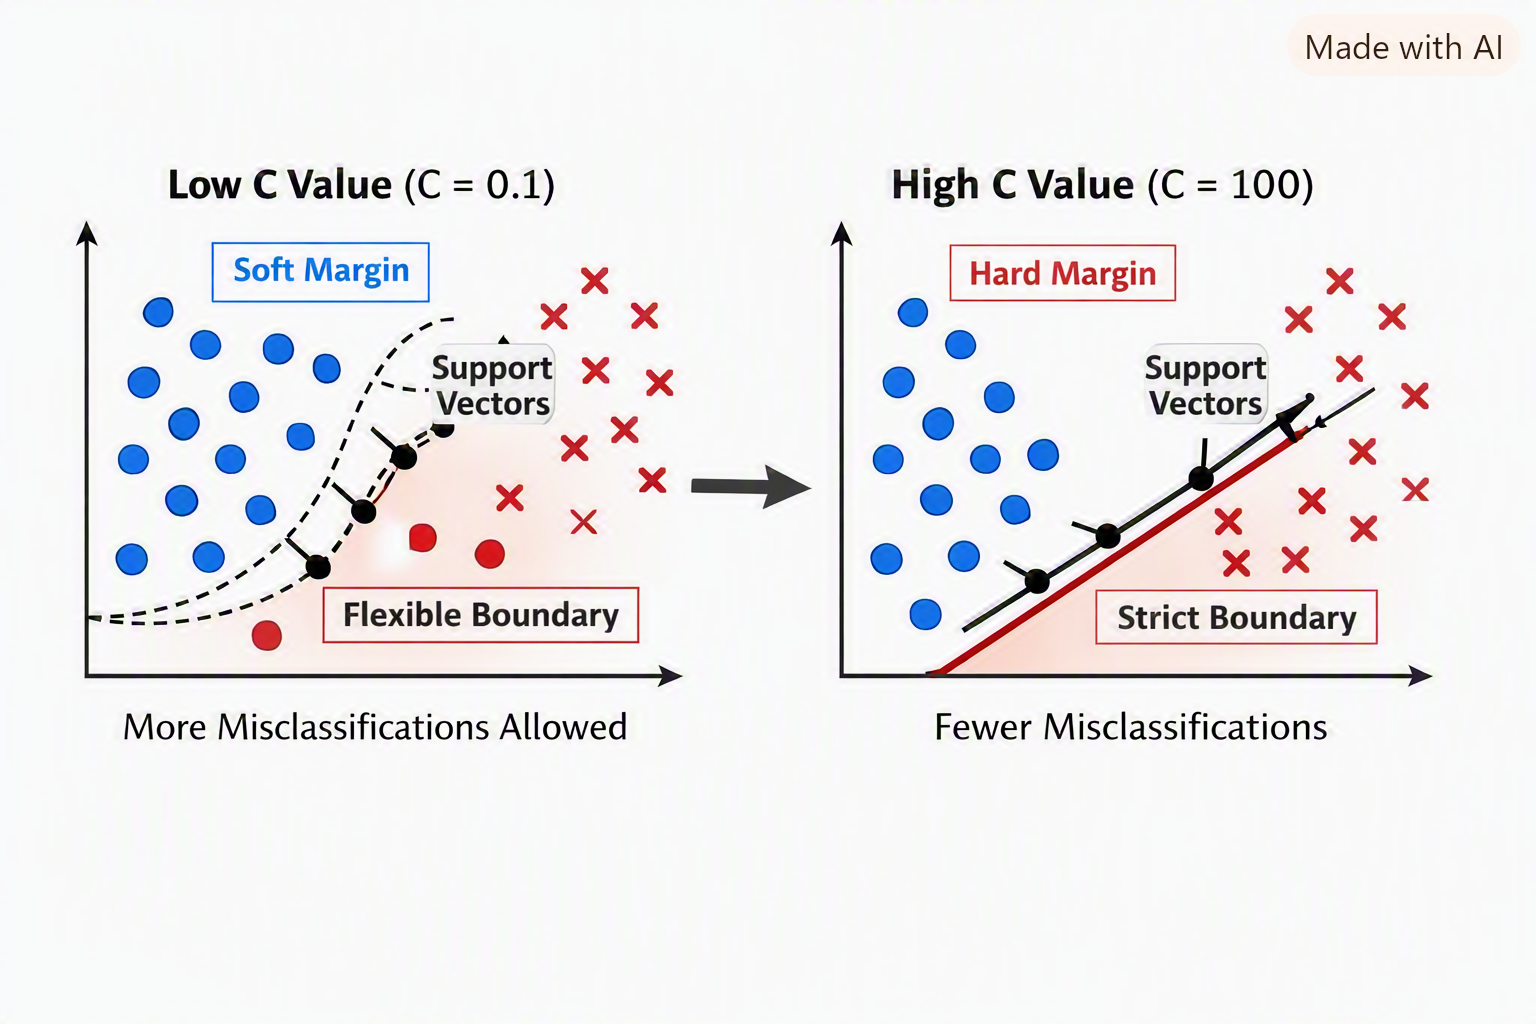

In [ ]:
#

## SVM Decision Boundary


In [ ]:
# see two or three columns
df.head()

In [ ]:
X_2d = df[['pH', 'alcohol']]
y_2d = (df['quality']>=7).astype(int)

In [ ]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

In [ ]:
# new pipleline
svm_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", SVC(kernel = 'poly', C=1))
])

svm_2d.fit(X_train_2d, y_train_2d)

In [ ]:
# plot the hyperplane

x_min = X_2d.iloc[:, 0].min() - 0.5
x_max = X_2d.iloc[:, 0].max() + 0.5
y_min = X_2d.iloc[:, 1].min() - 0.5
y_max = X_2d.iloc[:, 1].max() + 0.5


xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), # Reduced step size
                     np.arange(y_min, y_max, 0.02))

grid = np.c_[xx.ravel(), yy.ravel()]


# density function
Z = svm_2d.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

#plot observations for 'Not Good' (0)
plt.scatter(
    X_train_2d[y_train_2d == 0].iloc[:, 0],
    X_train_2d[y_train_2d == 0].iloc[:, 1],
    label = "Not Good",
    color = 'red', # Differentiate with color
    alpha = 0.6
)

#plot observations for 'Good' (1)
plt.scatter(
    X_train_2d[y_train_2d == 1].iloc[:, 0],
    X_train_2d[y_train_2d == 1].iloc[:, 1],
    label = "Good",
    color = 'blue', # Differentiate with color
    alpha = 0.6
)

# plot boundary and margins
plt.contour(
            xx,
            yy,
            Z,
            colors = 'k',
            levels = [-1, 0, 1], # Include levels for margins and decision boundary
            alpha = 0.8,
            linestyles = ['--', '-', '--'],
            linewidth = 3 # Dashed for margins, solid for boundary
)

plt.xlabel(X_2d.columns[0]) # Label axes dynamically
plt.ylabel(X_2d.columns[1]) # Label axes dynamically
plt.title('SVM Decision Boundary with Polynomial Kernel (and Margins)') # Updated title
plt.legend()
plt.show()

## SVM Decision Boundary with Linear Kernel (2D)

In [ ]:
# New pipeline for a Linear SVM in 2D
linear_svm_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", SVC(kernel='linear', C=1))
])

linear_svm_2d.fit(X_train_2d, y_train_2d)

print("Linear SVM (2D) model trained successfully.")

In [ ]:
# Plotting for Linear SVM

x_min = X_2d.iloc[:, 0].min() - 0.5
x_max = X_2d.iloc[:, 0].max() + 0.5
y_min = X_2d.iloc[:, 1].min() - 0.5
y_max = X_2d.iloc[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid = np.c_[xx.ravel(), yy.ravel()]

# Get the decision function from the trained linear SVM
Z_linear = linear_svm_2d.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Plot observations for 'Not Good' (0)
plt.scatter(
    X_train_2d[y_train_2d == 0].iloc[:, 0],
    X_train_2d[y_train_2d == 0].iloc[:, 1],
    label = "Not Good",
    color = 'red',
    alpha = 0.6
)

# Plot observations for 'Good' (1)
plt.scatter(
    X_train_2d[y_train_2d == 1].iloc[:, 0],
    X_train_2d[y_train_2d == 1].iloc[:, 1],
    label = "Good",
    color = 'blue',
    alpha = 0.6
)

# Plot decision boundary and margins
plt.contour(
            xx,
            yy,
            Z_linear,
            colors = 'k',
            levels = [-1, 0, 1],
            alpha = 0.8,
            linestyles = ['--', '-', '--'],
            linewidths = 3
)

# Plot support vectors
# Access the SVC estimator from the pipeline to get support_vectors_
support_vectors = linear_svm_2d.named_steps['linear_svc'].support_vectors_
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=100, facecolors='none', edgecolors='green', linewidth=1.5,
    label='Support Vectors'
)


plt.xlabel(X_2d.columns[0])
plt.ylabel(X_2d.columns[1])
plt.title('Linear SVM Decision Boundary with Support Vectors (pH vs Alcohol)')
plt.legend()
plt.show()

In [ ]:
# Access coefficients and intercept from the trained linear SVM
linear_svc_model = linear_svm_2d.named_steps['linear_svc']

coefficients = linear_svc_model.coef_[0]
intercept = linear_svc_model.intercept_[0]

feature_names = X_2d.columns

print(f"Hyperplane Coefficients (w):\n{feature_names[0]}: {coefficients[0]:.4f}\n{feature_names[1]}: {coefficients[1]:.4f}")
print(f"Hyperplane Intercept (b): {intercept:.4f}")

# Equation of the hyperplane: w_1*x_1 + w_2*x_2 + b = 0
print(f"\nEquation of the hyperplane: {coefficients[0]:.4f}*{feature_names[0]} + {coefficients[1]:.4f}*{feature_names[1]} + {intercept:.4f} = 0")

## SVM Decision Boundary in 3D (Polynomial Kernel)

In [ ]:
# Access coefficients and intercept from the trained linear SVM
linear_svc_model = linear_svm_2d.named_steps['linear_svc']

coefficients = linear_svc_model.coef_[0]
intercept = linear_svc_model.intercept_[0]

feature_names = X_2d.columns

print(f"Hyperplane Coefficients (w):\n{feature_names[0]}: {coefficients[0]:.4f}\n{feature_names[1]}: {coefficients[1]:.4f}")
print(f"Hyperplane Intercept (b): {intercept:.4f}")

# Equation of the hyperplane: w_1*x_1 + w_2*x_2 + b = 0
print(f"\nEquation of the hyperplane: {coefficients[0]:.4f}*{feature_names[0]} + {coefficients[1]:.4f}*{feature_names[1]} + {intercept:.4f} = 0")

In [ ]:
# import dataset iris
df_iris = sns.load_dataset('iris')

df_iris.head()

In [ ]:
# delete all rows after 99
df_iris = df_iris.iloc[:100]
df.shape

In [ ]:
df_iris.species.value_counts()

In [ ]:
# lets make a SVm Classifier for findning species
X = df_iris.drop('species', axis=1)
y = df_iris['species']
#split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# the SVM
svm_linear = SVC(kernel='linear', C=10)
svm_linear.fit(X_train, y_train)

In [ ]:
# predict
y_predict = svm_linear.predict(X_test)

# classification report
print(classification_report(y_test, y_predict))
# confusion matrix

cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
# Select two features for 2D visualization from df_iris
X_iris_2d = df_iris[['petal_length', 'petal_width']]
y_iris = df_iris['species']

# Map species names to numerical values for SVM (e.g., setosa: 0, versicolor: 1)
# This is necessary because SVC expects numerical labels.
# Since df_iris.iloc[:100] was used, we only have 'setosa' and 'versicolor'.
y_iris_encoded = y_iris.map({'setosa': 0, 'versicolor': 1})

# Split data into training and testing sets
X_train_iris_2d, X_test_iris_2d, y_train_iris, y_test_iris = train_test_split(
    X_iris_2d, y_iris_encoded, test_size=0.2, random_state=42, stratify=y_iris_encoded
)

# Create a pipeline for a Linear SVM
linear_svm_iris_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", SVC(kernel='linear', C=10))
])

# Train the model
linear_svm_iris_2d.fit(X_train_iris_2d, y_train_iris)

print("Linear SVM (Iris 2D) model trained successfully.")

# --- Plotting the decision boundary, margins, and support vectors ---

# Define the ranges for the meshgrid
x_min, x_max = X_iris_2d.iloc[:, 0].min() - 0.1, X_iris_2d.iloc[:, 0].max() + 0.1
y_min, y_max = X_iris_2d.iloc[:, 1].min() - 0.1, X_iris_2d.iloc[:, 1].max() + 0.1

# Create a dense meshgrid for plotting
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_iris = np.c_[xx.ravel(), yy.ravel()]

# Get the decision function from the trained linear SVM
Z_iris_linear = linear_svm_iris_2d.decision_function(grid_iris).reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Plot observations for 'setosa' (0)
plt.scatter(
    X_train_iris_2d[y_train_iris == 0].iloc[:, 0],
    X_train_iris_2d[y_train_iris == 0].iloc[:, 1],
    label = "Setosa",
    color = 'red',
    alpha = 0.6
)

# Plot observations for 'versicolor' (1)
plt.scatter(
    X_train_iris_2d[y_train_iris == 1].iloc[:, 0],
    X_train_iris_2d[y_train_iris == 1].iloc[:, 1],
    label = "Versicolor",
    color = 'blue',
    alpha = 0.6
)

# Plot decision boundary and margins
plt.contour(
            xx,
            yy,
            Z_iris_linear,
            colors = 'k',
            levels = [-1, 0, 1],
            alpha = 0.8,
            linestyles = ['--', '-', '--'],
            linewidths = 3
)

# Plot support vectors
# Access the SVC estimator from the pipeline to get support_vectors_
support_vectors_iris = linear_svm_iris_2d.named_steps['linear_svc'].support_vectors_
plt.scatter(
    support_vectors_iris[:, 0],
    support_vectors_iris[:, 1],
    s=100, facecolors='none', edgecolors='green', linewidth=1.5,
    label='Support Vectors'
)


plt.xlabel(X_iris_2d.columns[0])
plt.ylabel(X_iris_2d.columns[1])
plt.title('Linear SVM Decision Boundary with Support Vectors (Iris: Petal Length vs Petal Width)')
plt.legend()
plt.show()

# --- Displaying Hyperplane Object Created ---

# Access coefficients and intercept from the trained linear SVM
linear_svc_model_iris = linear_svm_iris_2d.named_steps['linear_svc']

coefficients_iris = linear_svc_model_iris.coef_[0]
intercept_iris = linear_svc_model_iris.intercept_[0]

feature_names_iris = X_iris_2d.columns

print(f"\nHyperplane Coefficients (w):\n{feature_names_iris[0]}: {coefficients_iris[0]:.4f}\n{feature_names_iris[1]}: {coefficients_iris[1]:.4f}")
print(f"Hyperplane Intercept (b): {intercept_iris:.4f}")

# Equation of the hyperplane: w_1*x_1 + w_2*x_2 + b = 0
print(f"\nEquation of the hyperplane: {coefficients_iris[0]:.4f}*{feature_names_iris[0]} + {coefficients_iris[1]:.4f}*{feature_names_iris[1]} + {intercept_iris:.4f} = 0")

In [ ]:
# lets make a SVm Classifier for findning species
X = df_iris.drop('species', axis=1)
y = df_iris['species']
#split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# the SVM
svm_poly = SVC(kernel='poly', C=10)
svm_poly.fit(X_train, y_train)

In [ ]:
# predictions
# predict
y_predict = svm_poly.predict(X_test)

# classification report
print(classification_report(y_test, y_predict))
# confusion matrix

cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
# Select two features for 2D visualization from df_iris
X_iris_2d = df_iris[['petal_length', 'petal_width']]
y_iris = df_iris['species']

# Map species names to numerical values for SVM (e.g., setosa: 0, versicolor: 1)
# This is necessary because SVC expects numerical labels.
# Since df_iris.iloc[:100] was used, we only have 'setosa' and 'versicolor'.
y_iris_encoded = y_iris.map({'setosa': 0, 'versicolor': 1})

# Split data into training and testing sets
X_train_iris_2d, X_test_iris_2d, y_train_iris, y_test_iris = train_test_split(
    X_iris_2d, y_iris_encoded, test_size=0.2, random_state=42, stratify=y_iris_encoded
)

# Create a pipeline for a Poly SVM
poly_svm_iris_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_svc", SVC(kernel='poly', C=10))
])

# train the model
poly_svm_iris_2d.fit(X_train_iris_2d, y_train_iris)

print("Poly SVM (Iris 2D) model trained successfully.")



In [ ]:
# Define the ranges for the meshgrid using X_iris_2d (petal_length, petal_width)
x_min, x_max = X_iris_2d.iloc[:, 0].min() - 0.1, X_iris_2d.iloc[:, 0].max() + 0.1
y_min, y_max = X_iris_2d.iloc[:, 1].min() - 0.1, X_iris_2d.iloc[:, 1].max() + 0.1

# Create a dense meshgrid for plotting
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_iris = np.c_[xx.ravel(), yy.ravel()]

# Get the decision function from the trained polynomial SVM
Z_iris_poly = poly_svm_iris_2d.decision_function(grid_iris).reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Plot observations for 'setosa' (0)
plt.scatter(
    X_train_iris_2d[y_train_iris == 0].iloc[:, 0],
    X_train_iris_2d[y_train_iris == 0].iloc[:, 1],
    label="Setosa",
    color='red',
    alpha=0.6
)

# Plot observations for 'versicolor' (1)
plt.scatter(
    X_train_iris_2d[y_train_iris == 1].iloc[:, 0],
    X_train_iris_2d[y_train_iris == 1].iloc[:, 1],
    label="Versicolor",
    color='blue',
    alpha=0.6
)

# Plot decision boundary and margins
plt.contour(
    xx,
    yy,
    Z_iris_poly,
    colors='k',
    levels=[-1, 0, 1],
    alpha=0.8,
    linestyles=['--', '-', '--'],
    linewidths=3
)

# Plot support vectors
support_vectors_poly_iris = poly_svm_iris_2d.named_steps['poly_svc'].support_vectors_
plt.scatter(
    support_vectors_poly_iris[:, 0],
    support_vectors_poly_iris[:, 1],
    s=100, facecolors='none', edgecolors='green', linewidth=1.5,
    label='Support Vectors'
)

plt.xlabel(X_iris_2d.columns[0])
plt.ylabel(X_iris_2d.columns[1])
plt.title('Polynomial SVM Decision Boundary with Support Vectors (Iris: Petal Length vs Petal Width)')
plt.legend()
plt.show()

# Displaying Hyperplane Object Created (kernel parameters for polynomial)
poly_svc_model_iris = poly_svm_iris_2d.named_steps['poly_svc']
print(f"\nPolynomial SVM Kernel: {poly_svc_model_iris.kernel}")
print(f"Regularization parameter (C): {poly_svc_model_iris.C}")
print(f"Degree of polynomial kernel: {poly_svc_model_iris.degree}")

## 3D SVM Decision Boundary with Polynomial Kernel (Iris Dataset)

In [ ]:
# Select three features for 3D visualization from df_iris
X_iris_3d = df_iris[['petal_length', 'petal_width', 'sepal_length']]
y_iris = df_iris['species']

# Map species names to numerical values for SVM
y_iris_encoded = y_iris.map({'setosa': 0, 'versicolor': 1})

# Split data into training and testing sets
X_train_iris_3d, X_test_iris_3d, y_train_iris_3d, y_test_iris_3d = train_test_split(
    X_iris_3d, y_iris_encoded, test_size=0.2, random_state=42, stratify=y_iris_encoded
)

# Create a pipeline for a Polynomial SVM in 3D
poly_svm_iris_3d = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_svc", SVC(kernel='poly', C=10, degree=3)) # Using degree=3 for a cubic polynomial
])

# Train the model
poly_svm_iris_3d.fit(X_train_iris_3d, y_train_iris_3d)

print("Polynomial SVM (Iris 3D) model trained successfully.")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot observations for 'setosa' (0)
ax.scatter(
    X_train_iris_3d[y_train_iris_3d == 0]['petal_length'],
    X_train_iris_3d[y_train_iris_3d == 0]['petal_width'],
    X_train_iris_3d[y_train_iris_3d == 0]['sepal_length'],
    label='Setosa',
    color='red',
    alpha=0.6,
    marker='o'
)

# Plot observations for 'versicolor' (1)
ax.scatter(
    X_train_iris_3d[y_train_iris_3d == 1]['petal_length'],
    X_train_iris_3d[y_train_iris_3d == 1]['petal_width'],
    X_train_iris_3d[y_train_iris_3d == 1]['sepal_length'],
    label='Versicolor',
    color='blue',
    alpha=0.6,
    marker='^'
)

# Define the ranges for the meshgrid for petal_length and petal_width
x_min, x_max = X_iris_3d['petal_length'].min() - 0.1, X_iris_3d['petal_length'].max() + 0.1
y_min, y_max = X_iris_3d['petal_width'].min() - 0.1, X_iris_3d['petal_width'].max() + 0.1

# Create 2D meshgrid for petal_length and petal_width
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Define a few `sepal_length` values for slices of the decision boundary
z_values_for_slices = np.linspace(X_iris_3d['sepal_length'].min(), X_iris_3d['sepal_length'].max(), 3) # 3 slices

# Plot decision boundary and margins for each slice of sepal_length
for z_slice in z_values_for_slices:
    # Create a 3D grid for the current slice
    grid_slice = np.c_[xx.ravel(), yy.ravel(), np.full_like(xx.ravel(), z_slice)]

    # Get the decision function from the trained polynomial SVM
    Z_iris_poly_3d_slice = poly_svm_iris_3d.decision_function(grid_slice).reshape(xx.shape)

    # Plot filled contours for regions (Class 0, Class 1, Margin)
    ax.contourf(xx, yy, Z_iris_poly_3d_slice, levels=[-np.inf, -1], colors=['#FFDDDD'], alpha=0.2, zdir='z', offset=z_slice) # Class 0 region (light red)
    ax.contourf(xx, yy, Z_iris_poly_3d_slice, levels=[1, np.inf], colors=['#DDDDFF'], alpha=0.2, zdir='z', offset=z_slice) # Class 1 region (light blue)

    # Plot contour for the decision boundary (level 0)
    ax.contour(xx, yy, Z_iris_poly_3d_slice, levels=[0], colors='k', linestyles='-', linewidths=3, zdir='z', offset=z_slice)

    # Plot contours for the margins (levels -1 and 1)
    ax.contour(xx, yy, Z_iris_poly_3d_slice, levels=[-1, 1], colors='k', linestyles='--', linewidths=2, zdir='z', offset=z_slice)

ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_zlabel('Sepal Length')
ax.set_title('Polynomial SVM 3D Decision Boundary Slices (Iris: Petal Length, Petal Width, Sepal Length)')
ax.legend()
plt.show()

# Displaying Hyperplane Object Created (kernel parameters for polynomial SVM)
poly_svc_model_iris_3d = poly_svm_iris_3d.named_steps['poly_svc']
print(f"\nPolynomial SVM Kernel: {poly_svc_model_iris_3d.kernel}")
print(f"Regularization parameter (C): {poly_svc_model_iris_3d.C}")
print(f"Degree of polynomial kernel: {poly_svc_model_iris_3d.degree}")
print(f"Gamma parameter: {poly_svc_model_iris_3d.gamma}")

# SVM Regression

In [ ]:
df.quality.value_counts()

In [ ]:
y = df['quality']
X = df.drop('quality', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# linear SVR
linear_svr = Pipeline([

                       ('scaler', StandardScaler()),
                       ('linear_svr', SVR(kernel='linear', C=1))
])

linear_svr.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# predictions
y_predict = linear_svr.predict(X_test)

# metrics
print(f"MSE: {mean_squared_error(y_test, y_predict)}")
print(f"MAE: {mean_absolute_error(y_test, y_predict)}")
print(f"R2: {r2_score(y_test, y_predict)}")


In [ ]:
# plot this model of regression via scatter and line plot

plt.figure(figsize=(10, 7))

# Choose a single feature for visualization, e.g., 'alcohol'
# Ensure X_train is a DataFrame, then select a column
X_train_feature = X_train['alcohol'].values.reshape(-1, 1) # Reshape for StandardScaler and SVR predict
X_test_feature = X_test['alcohol'].values.reshape(-1, 1)

# Create a simplified SVR pipeline for plotting this single feature
linear_svr_single_feature = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svr', SVR(kernel='linear', C=1))
])

# Fit the simplified model on the single feature
linear_svr_single_feature.fit(X_train_feature, y_train)

# Scatter of actual values (using the 'alcohol' feature from X_train)
plt.scatter(X_train['alcohol'], y_train, label='Actual Training Values', alpha=0.6)

# Generate predictions for the line plot over a range of the selected feature
alcohol_range = np.linspace(X_train['alcohol'].min(), X_train['alcohol'].max(), 100).reshape(-1, 1)
y_predict_line = linear_svr_single_feature.predict(alcohol_range)

# Line of prediction
plt.plot(alcohol_range, y_predict_line, color='red', label='SVR Prediction Line')

plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Linear SVR Regression Line vs Actual Values (Alcohol)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# epsilon values
epsilon_values = [0.01, 0.1]

for epsilon in epsilon_values:
    svr_model = SVR(kernel='linear', C=1, epsilon=epsilon)
    svr_model.fit(X_train, y_train)
    y_predict = svr_model.predict(X_test)
    mse = mean_squared_error(y_test, y_predict)
    mae = mean_absolute_error(y_test, y_predict)
    r2 = r2_score(y_test, y_predict)
    print(f"Epsilon: {epsilon}")
    print(f"MSE: {mse}")
    print(f"MAE: {mae}")
    print(f"R2: {r2}")
    print("\n")